In [1]:
import zipfile
import os

# Upload the zip file
from google.colab import files
uploaded = files.upload()

# Extract the ZIP file
zip_file_path = '/content/drive/MyDrive/Defence/ppg_bp_0_subject/archive.zip'  # Replace with your file's name
extract_dir = '/content/ppg_bp_0_subject'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# List extracted files
os.listdir(extract_dir)


Saving archive (3).zip to archive (3).zip


['34_2.txt',
 '403_3.txt',
 '9_2.txt',
 '205_3.txt',
 '173_3.txt',
 '245_3.txt',
 '131_1.txt',
 '229_2.txt',
 '190_2.txt',
 '247_3.txt',
 '205_1.txt',
 '108_1.txt',
 '195_2.txt',
 '103_3.txt',
 '137_3.txt',
 '259_3.txt',
 '91_3.txt',
 '234_1.txt',
 '43_3.txt',
 '2_2.txt',
 '57_1.txt',
 '30_3.txt',
 '192_1.txt',
 '152_2.txt',
 '136_3.txt',
 '113_2.txt',
 '175_1.txt',
 '251_3.txt',
 '140_2.txt',
 '217_2.txt',
 '51_3.txt',
 '98_3.txt',
 '221_3.txt',
 '161_2.txt',
 '246_1.txt',
 '234_2.txt',
 '160_2.txt',
 '93_3.txt',
 '150_2.txt',
 '100_1.txt',
 '115_2.txt',
 '145_1.txt',
 '411_2.txt',
 '189_2.txt',
 '41_2.txt',
 '191_3.txt',
 '63_2.txt',
 '27_1.txt',
 '248_3.txt',
 '55_1.txt',
 '112_3.txt',
 '257_2.txt',
 '58_3.txt',
 '415_3.txt',
 '182_1.txt',
 '417_1.txt',
 '234_3.txt',
 '135_2.txt',
 '111_2.txt',
 '216_2.txt',
 '242_2.txt',
 '10_1.txt',
 '206_1.txt',
 '116_2.txt',
 '22_1.txt',
 '134_2.txt',
 '67_3.txt',
 '157_3.txt',
 '64_3.txt',
 '89_3.txt',
 '409_1.txt',
 '197_1.txt',
 '413_1.txt',


In [2]:
import pandas as pd

# Read demographic data from the Excel file
demographic_data = pd.read_excel(os.path.join(extract_dir, 'PPG-BP dataset.xlsx'))

# Clean the data by setting correct column headers
demographic_data.columns = demographic_data.iloc[0]  # Set the first row as column headers
demographic_data = demographic_data.drop(0)  # Drop the first row since it's now the header

demographic_data.head()  # Check the cleaned data


,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
1,1,2,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
2,2,3,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN
3,3,6,Female,47,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN
4,4,8,Male,45,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN
5,5,9,Female,46,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN


In [3]:
import numpy as np

# Function to read and combine PPG data for a subject
def read_ppg_data(subject_id):
    ppg_data = []
    for i in range(1, 4):  # Files 1, 2, 3
        file_name = f"{subject_id}_{i}.txt"
        file_path = os.path.join(extract_dir, file_name)
        if os.path.exists(file_path):
            # Read the file
            data = np.loadtxt(file_path)
            ppg_data.append(data)
    # Combine the data from all three files into one array
    return np.concatenate(ppg_data, axis=0)

# Combine PPG data for all subjects
combined_ppg_data = {}
for _, row in demographic_data.iterrows():
    subject_id = row['subject_ID']
    combined_ppg_data[subject_id] = read_ppg_data(subject_id)


In [5]:
combined_data = []
max_ppg_length = 0

# Find the maximum PPG data length across all subjects
for _, row in demographic_data.iterrows():
    subject_id = row['subject_ID']
    try:
        ppg_data = combined_ppg_data[subject_id]
        max_ppg_length = max(max_ppg_length, len(ppg_data))
    except KeyError:
        continue

for _, row in demographic_data.iterrows():
    subject_id = row['subject_ID']
    try:
        ppg_data = combined_ppg_data[subject_id]
    except KeyError:
        continue

    # Pad PPG data if necessary to match the maximum length
    if len(ppg_data) < max_ppg_length:
        padding = np.full((max_ppg_length - len(ppg_data)), np.nan)
        ppg_data = np.concatenate([ppg_data, padding])

    demographic_info = row[['Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
                            'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
                            'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
                            'cerebral infarction', 'cerebrovascular disease']].values.astype(object) # convert to object to allow concatenation with NaNs

    combined_row = np.concatenate([ppg_data, demographic_info])
    combined_data.append(combined_row)

# Convert to DataFrame
columns = [f'PPG_{i+1}' for i in range(max_ppg_length)] + [
    'Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
    'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
    'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
    'cerebral infarction', 'cerebrovascular disease'
]

# Create DataFrame
combined_df = pd.DataFrame(combined_data, columns=columns)

In [10]:
combined_data = []
max_ppg_length = 0

# Find the maximum PPG data length across all subjects
for _, row in demographic_data.iterrows():
    subject_id = row['subject_ID']
    try:
        ppg_data = combined_ppg_data[subject_id]
        max_ppg_length = max(max_ppg_length, len(ppg_data))
    except KeyError:
        continue

for _, row in demographic_data.iterrows():
    subject_id = row['subject_ID']
    try:
        ppg_data = combined_ppg_data[subject_id]
    except KeyError:
        continue

    # Pad PPG data if necessary to match the maximum length
    if len(ppg_data) < max_ppg_length:
        padding = np.full((max_ppg_length - len(ppg_data)), np.nan)
        ppg_data = np.concatenate([ppg_data, padding])

    demographic_info = row[['Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
                            'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
                            'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
                            'cerebral infarction', 'cerebrovascular disease']].values.astype(object) # convert to object to allow concatenation with NaNs

    combined_row = np.concatenate([demographic_info, ppg_data])
    combined_data.append(combined_row)

# Convert to DataFrame
columns = [
    'Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)',
    'Systolic Blood Pressure(mmHg)', 'Diastolic Blood Pressure(mmHg)',
    'Heart Rate(b/m)', 'BMI(kg/m^2)', 'Hypertension', 'Diabetes',
    'cerebral infarction', 'cerebrovascular disease'
] + [f'PPG_{i+1}' for i in range(max_ppg_length)]

# Create DataFrame
combined_df2 = pd.DataFrame(combined_data, columns=columns)

In [11]:
display(combined_df2.head())

,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,...,PPG_10491,PPG_10492,PPG_10493,PPG_10494,PPG_10495,PPG_10496,PPG_10497,PPG_10498,PPG_10499,PPG_10500
0,Female,45,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Female,50,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Female,47,150,47,101,71,79,20.888889,Normal,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Male,45,172,65,136,93,87,21.971336,Prehypertension,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Female,46,155,65,123,73,73,27.055151,Prehypertension,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(combined_df2.head())

  Sex(M/F)  Age(year)  Height(cm)  Weight(kg)  Systolic Blood Pressure(mmHg)  \
0   Female         45         152          63                            161   
1   Female         50         157          50                            160   
2   Female         47         150          47                            101   
3     Male         45         172          65                            136   
4   Female         46         155          65                            123   

   Diastolic Blood Pressure(mmHg)  Heart Rate(b/m)  BMI(kg/m^2)  \
0                              89               97    27.268006   
1                              93               76    20.284799   
2                              71               79    20.888889   
3                              93               87    21.971336   
4                              73               73    27.055151   

           Hypertension Diabetes  ... PPG_10491 PPG_10492  PPG_10493  \
0  Stage 2 hypertension      NaN  ...       

In [6]:
# Save to CSV
combined_df.to_csv('/content/combined_ppg_data.csv', index=False)


In [7]:
from google.colab import files
files.download('/content/combined_ppg_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
display(combined_df.head())

,PPG_1,PPG_2,PPG_3,PPG_4,PPG_5,PPG_6,PPG_7,PPG_8,PPG_9,PPG_10,...,Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,2438.0,2438.0,2438.0,2455.0,2455.0,2384.0,2384.0,2384.0,2418.0,2418.0,...,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
1,1973.0,1973.0,1990.0,1990.0,1979.0,1979.0,1979.0,1956.0,1956.0,1965.0,...,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN
2,2003.0,2003.0,1978.0,1978.0,1978.0,1993.0,1993.0,1986.0,1986.0,1986.0,...,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN
3,2039.0,2039.0,2039.0,2029.0,2029.0,2042.0,2042.0,2042.0,2044.0,2044.0,...,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN
4,1961.0,1971.0,1971.0,1971.0,1964.0,1964.0,1968.0,1968.0,1968.0,1994.0,...,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN


In [14]:
# Create a dataset with only PPG data and the subject_ID
ppg_data_only = []

# Add subject ID as the first column and corresponding PPG data as subsequent columns
for subject_id in demographic_data['subject_ID']:
    try:
        ppg_data = combined_ppg_data[subject_id]  # Get PPG data
        # Pad PPG data if necessary to match the maximum length
        if len(ppg_data) < max_ppg_length:
            padding = np.full((max_ppg_length - len(ppg_data)), np.nan)
            ppg_data = np.concatenate([ppg_data, padding])

        ppg_data_only.append([subject_id] + list(ppg_data))  # Add subject ID to the start of the data
    except KeyError:
        continue  # Skip subjects without PPG data

# Create DataFrame with PPG data only
columns_ppg = ['subject_ID'] + [f'PPG_{i+1}' for i in range(max_ppg_length)]
ppg_df = pd.DataFrame(ppg_data_only, columns=columns_ppg)

# Save the PPG data dataframe
ppg_df.to_csv('/content/ppg_data_only.csv', index=False)

In [ ]:
# Load the labels data
labels_df = pd.read_csv("/content/labelsV2.csv")

# Load the PPG data
features_df = pd.read_csv("/content/featuresV2.csv")

# Merge the two dataframes on 'subject_ID'
oldData_df = pd.merge(features_df, labels_df)

# Calculate the correlation matrix
correlation_matrix = combined_correlation_df.corr()

# Display the correlation matrix (or a portion of it)
display(correlation_matrix)

In [16]:
# Load the labels data
labels_df = pd.read_csv("/content/labelsV2.csv")

# Load the features data
features_df = pd.read_csv("/content/featuresV2.csv")

# Merge the two dataframes by index
combined_correlation_df = pd.merge(features_df, labels_df, left_index=True, right_index=True)

# Calculate the correlation matrix
correlation_matrix = combined_correlation_df.corr()

# Display the correlation matrix (or a portion of it)
display(correlation_matrix)

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
ir_mean,1.000000,0.996106,-0.277440,0.676046,0.957363,-0.215137,-0.116791,-0.036643,0.042544,0.999517,...,NaN,-0.096606,-0.100772,-0.003412,-0.085002,-0.100829,0.010830,0.002983,-0.089608,-0.059678
ir_median,0.996106,1.000000,-0.218307,0.630764,0.958890,-0.159892,-0.163558,-0.013515,0.058633,0.997314,...,NaN,-0.097286,-0.105793,-0.002442,-0.089599,-0.107048,0.011648,0.008890,-0.087295,-0.061482
ir_std,-0.277440,-0.218307,1.000000,-0.830605,-0.077105,0.947991,-0.429571,0.404158,0.143445,-0.253753,...,NaN,0.018096,-0.023917,0.022449,0.033766,0.026169,-0.086740,0.016418,0.094654,0.070134
ir_min,0.676046,0.630764,-0.830605,1.000000,0.552846,-0.855193,0.353454,-0.478154,-0.154932,0.659449,...,NaN,-0.050196,-0.021121,-0.028663,-0.088229,-0.083347,0.091277,0.000809,-0.072730,-0.054361
ir_max,0.957363,0.958890,-0.077105,0.552846,1.000000,-0.040891,-0.126655,0.014165,0.016950,0.961555,...,NaN,-0.095074,-0.102045,-0.003600,-0.074588,-0.087042,-0.015794,0.006298,-0.053835,-0.026182
ir_range,-0.215137,-0.159892,0.947991,-0.855193,-0.040891,1.000000,-0.502596,0.582150,0.196317,-0.192628,...,NaN,0.001052,-0.038147,0.032130,0.059399,0.045797,-0.119272,0.002948,0.053722,0.048897
ir_skewness,-0.116791,-0.163558,-0.429571,0.353454,-0.126655,-0.502596,1.000000,-0.554618,-0.170877,-0.130294,...,NaN,-0.004621,0.026518,-0.024952,0.015089,0.042937,0.043878,-0.147481,0.009625,0.006902
ir_kurtosis,-0.036643,-0.013515,0.404158,-0.478154,0.014165,0.582150,-0.554618,1.000000,0.329636,-0.025874,...,NaN,-0.017495,-0.030548,0.001877,0.029600,0.021675,-0.132756,0.002357,-0.040822,-0.028832
ir_num_peaks,0.042544,0.058633,0.143445,-0.154932,0.016950,0.196317,-0.170877,0.329636,1.000000,0.045629,...,NaN,0.039721,0.121900,0.058913,0.074814,0.044145,-0.038332,-0.125767,-0.068695,-0.075371
ir_mean_peak_amplitude,0.999517,0.997314,-0.253753,0.659449,0.961555,-0.192628,-0.130294,-0.025874,0.045629,1.000000,...,NaN,-0.097313,-0.104151,-0.002829,-0.085797,-0.102201,0.008281,0.006104,-0.088491,-0.058316


In [17]:
display(combined_correlation_df.head())

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,0.0,44.0,1.0,180.0,98.0,30.246914,107.0,100.0,122,83
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,0.0,30.0,0.0,154.0,43.0,18.131219,125.0,100.0,102,68
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,0.0,61.0,0.0,144.0,62.0,29.899691,93.0,100.0,141,93
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,0.0,45.0,1.0,172.0,103.0,34.816117,71.0,98.0,139,96
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,0.0,23.0,1.0,172.0,88.0,29.745809,166.0,98.0,112,75


In [18]:
# Drop the specified columns
columns_to_drop = ['ir_low_freq_band', 'ir_high_freq_band', 'red_low_freq_band', 'red_high_freq_band']
combined_correlation_df = combined_correlation_df.drop(columns=columns_to_drop)

# Display the updated DataFrame head to confirm the columns are dropped
display(combined_correlation_df.head())

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_total_energy,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,2.982998e+13,44.0,1.0,180.0,98.0,30.246914,107.0,100.0,122,83
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,3.837467e+13,30.0,0.0,154.0,43.0,18.131219,125.0,100.0,102,68
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,8.062040e+13,61.0,0.0,144.0,62.0,29.899691,93.0,100.0,141,93
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,6.006732e+13,45.0,1.0,172.0,103.0,34.816117,71.0,98.0,139,96
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,8.233843e+13,23.0,1.0,172.0,88.0,29.745809,166.0,98.0,112,75


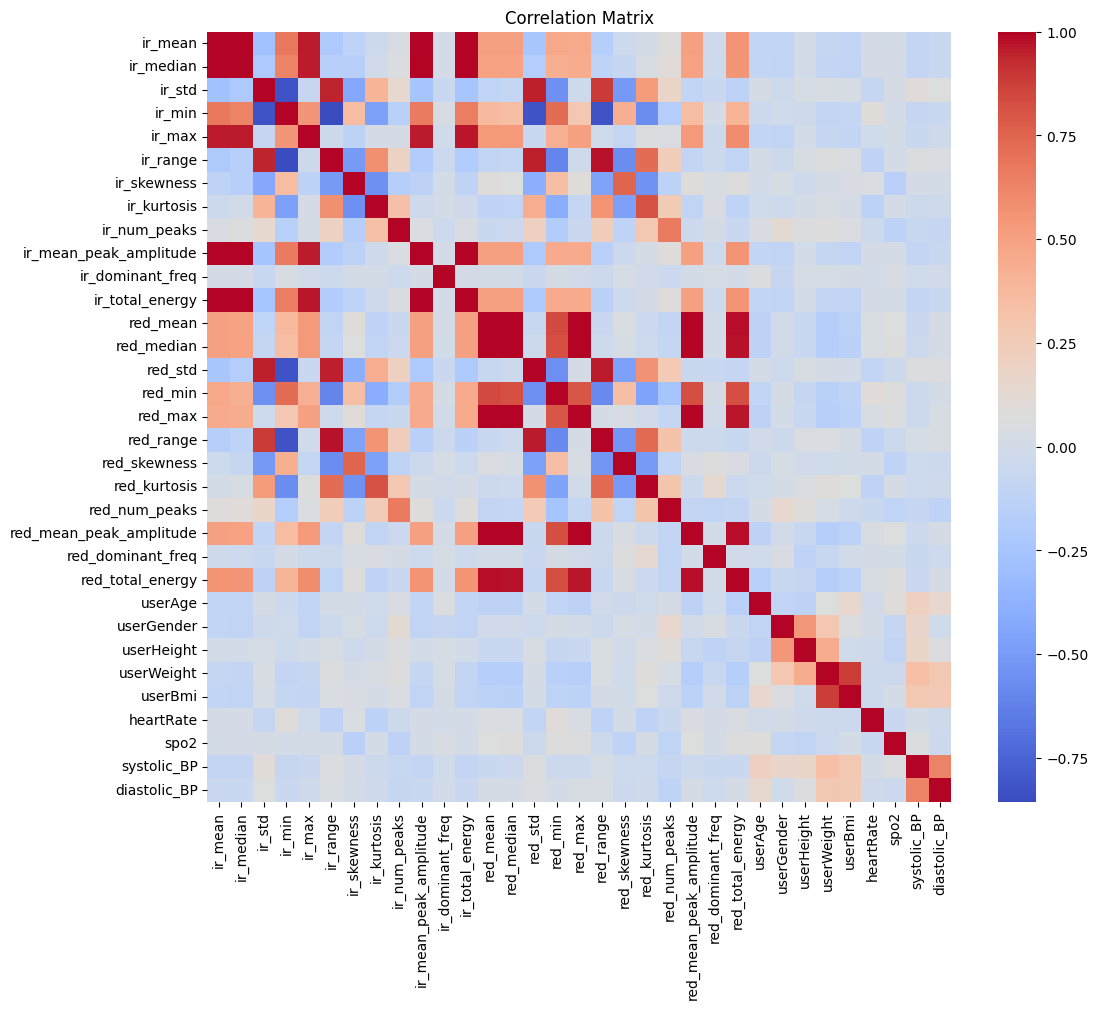

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = combined_correlation_df.corr()

# Set the figure size
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')

# Set the title
plt.title('Correlation Matrix')

# Display the plot
plt.show()

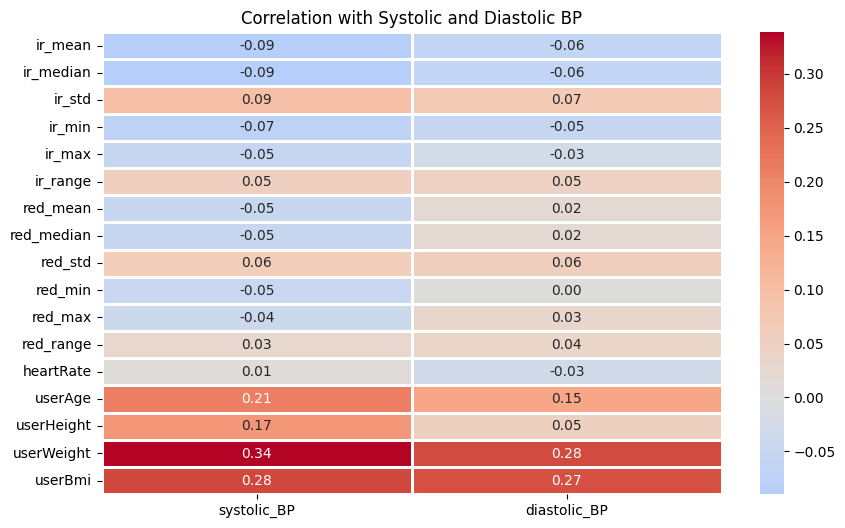

In [21]:
# Assuming you have the correlation matrix already computed in `corr_matrix`
# Let's extract the correlations for systolic and diastolic BP columns

bp_features = ['systolic_BP', 'diastolic_BP']
columns_of_interest = ['ir_mean', 'ir_median', 'ir_std', 'ir_min', 'ir_max', 'ir_range',
                       'red_mean', 'red_median', 'red_std', 'red_min', 'red_max', 'red_range',
                       'heartRate', 'userAge', 'userHeight', 'userWeight', 'userBmi']

# Extract the correlation values for the systolic and diastolic BP columns
correlation_with_bp = correlation_matrix[bp_features].loc[columns_of_interest]

# Plot the extracted correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_with_bp, annot=True, cmap='coolwarm', center=0, linewidths=1, fmt='.2f')
plt.title("Correlation with Systolic and Diastolic BP")
plt.show()


In [25]:
%whos

Variable                  Type         Data/Info
------------------------------------------------
bp_features               list         n=2
columns                   list         n=10512
columns_of_interest       list         n=17
columns_ppg               list         n=10501
columns_to_drop           list         n=4
combined_correlation_df   DataFrame              ir_mean     ir_<...>\n[317 rows x 33 columns]
combined_data             list         n=219
combined_df               DataFrame          PPG_1   PPG_2   PPG<...>219 rows x 10512 columns]
combined_df2              DataFrame        Sex(M/F)  Age(year)  <...>219 rows x 10512 columns]
combined_ppg_data         dict         n=219
combined_row              ndarray      10512: 10512 elems, type `object`, 84096 bytes
correlation_matrix        DataFrame                             <...>n\n[33 rows x 33 columns]
correlation_with_bp       DataFrame                systolic_BP  <...>   0.282502      0.272197
demographic_data          D

In [26]:
display(combined_df.head())

,PPG_1,PPG_2,PPG_3,PPG_4,PPG_5,PPG_6,PPG_7,PPG_8,PPG_9,PPG_10,...,Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,2438.0,2438.0,2438.0,2455.0,2455.0,2384.0,2384.0,2384.0,2418.0,2418.0,...,152,63,161,89,97,27.268006,Stage 2 hypertension,NaN,NaN,NaN
1,1973.0,1973.0,1990.0,1990.0,1979.0,1979.0,1979.0,1956.0,1956.0,1965.0,...,157,50,160,93,76,20.284799,Stage 2 hypertension,NaN,NaN,NaN
2,2003.0,2003.0,1978.0,1978.0,1978.0,1993.0,1993.0,1986.0,1986.0,1986.0,...,150,47,101,71,79,20.888889,Normal,NaN,NaN,NaN
3,2039.0,2039.0,2039.0,2029.0,2029.0,2042.0,2042.0,2042.0,2044.0,2044.0,...,172,65,136,93,87,21.971336,Prehypertension,NaN,NaN,NaN
4,1961.0,1971.0,1971.0,1971.0,1964.0,1964.0,1968.0,1968.0,1968.0,1994.0,...,155,65,123,73,73,27.055151,Prehypertension,NaN,NaN,NaN


In [22]:
# Install necessary packages if not already installed
!pip install scipy

# Import libraries
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import find_peaks
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt


In [27]:
# Define a function to calculate statistical features
def extract_statistical_features(signal):
    mean = np.mean(signal)
    std = np.std(signal)
    skewness = skew(signal)
    kurt = kurtosis(signal)
    min_val = np.min(signal)
    max_val = np.max(signal)
    range_val = max_val - min_val
    entropy = -np.sum(np.log(signal + 1e-9) * signal)  # Simple entropy calculation (avoid log(0))

    return [mean, std, skewness, kurt, min_val, max_val, range_val, entropy]

# Example for extracting features from a PPG signal (say PPG_1)
features_ppg_1 = extract_statistical_features(combined_df['PPG_1'].values)
print(features_ppg_1)


[np.float64(2083.24200913242), np.float64(337.3497986320124), np.float64(1.5771179553476913), np.float64(4.42621429457974), np.float64(1404.0), np.float64(3900.0), np.float64(2496.0), np.float64(-3491981.2932162597)]


In [28]:
# Function to calculate frequency features
def extract_frequency_features(signal, fs=1000):  # Assuming 1000 Hz sampling frequency
    # Perform FFT
    N = len(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)
    fft_vals = fft(signal)

    # Remove negative frequencies
    fft_vals = fft_vals[freqs > 0]
    freqs = freqs[freqs > 0]

    # Dominant frequency (highest peak in the spectrum)
    dominant_freq = freqs[np.argmax(np.abs(fft_vals))]

    # Spectral energy (sum of squared magnitudes)
    spectral_energy = np.sum(np.abs(fft_vals)**2)

    # Bandpower (power in the frequency range, example 0.5-4 Hz for a specific band)
    bandpower = np.sum(np.abs(fft_vals[(freqs > 0.5) & (freqs < 4.0)])**2)  # Modify frequency bands as needed

    return [dominant_freq, spectral_energy, bandpower]

# Example for extracting frequency features from PPG_1
freq_features = extract_frequency_features(combined_df['PPG_1'].values)
print(freq_features)


[np.float64(9.132420091324201), np.float64(2729098084.0), np.float64(0.0)]


In [29]:
# Function to calculate morphological features
def extract_morphological_features(signal):
    # Find peaks in the signal
    peaks, _ = find_peaks(signal)
    peak_count = len(peaks)

    # Mean amplitude (average height of peaks)
    peak_amplitude = np.mean(signal[peaks]) if peak_count > 0 else 0

    # Inter-peak interval (time difference between consecutive peaks)
    if peak_count > 1:
        inter_peak_interval = np.diff(peaks)
    else:
        inter_peak_interval = [0]

    return [peak_count, peak_amplitude, np.mean(inter_peak_interval)]

# Example for extracting morphological features from PPG_1
morph_features = extract_morphological_features(combined_df['PPG_1'].values)
print(morph_features)


[73, np.float64(2337.3835616438355), np.float64(2.9583333333333335)]


In [32]:
# Combine statistical, frequency, morphological, and IR/Red ratio features
all_features = []

for i in range(1, 11):  # Adjust based on how many PPG signals you want to process
    ppg_signal = f'PPG_{i}'
    stat_feats = extract_statistical_features(combined_df[ppg_signal].values)
    freq_feats = extract_frequency_features(combined_df[ppg_signal].values)
    morph_feats = extract_morphological_features(combined_df[ppg_signal].values)

    # Combine features for each signal

    all_features.append(stat_feats + freq_feats + morph_feats)

# Create a DataFrame from the extracted features
columns = ['mean', 'std', 'skew', 'kurt', 'min', 'max', 'range', 'entropy',
           'dominant_freq', 'spectral_energy', 'bandpower',
           'peak_count', 'mean_amplitude', 'inter_peak_interval']

features_df = pd.DataFrame(all_features, columns=columns)

# Add demographic information (e.g., heart rate, systolic BP, diastolic BP)
features_df['heartRate'] = combined_df['Heart Rate(b/m)']
features_df['systolic_BP'] = combined_df['Systolic Blood Pressure(mmHg)']
features_df['diastolic_BP'] = combined_df['Diastolic Blood Pressure(mmHg)']
features_df['userAge'] = combined_df['Age(year)']
features_df['userHeight'] = combined_df['Height(cm)']
features_df['userWeight'] = combined_df['Weight(kg)']
features_df['userBmi'] = combined_df['BMI(kg/m^2)']

# Save the final features DataFrame
features_df.to_csv('/content/extracted_features_ppg_online.csv', index=False)

In [33]:
from google.colab import files
files.download('/content/extracted_features_ppg_online.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>